In [1]:
library(Seurat)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.3 but the current
version is 1.7.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
first_existing_file <- function(paths, label) {
  existing <- paths[file.exists(paths)]
  if (length(existing) == 0) {
    stop(
      label, " was not found. Checked:\n",
      paste0("  - " , paths, collapse = "\n"),
      call. = FALSE
    )
  }
  existing[[1]]
}

ec_candidates <- c(
  "Fig1_EC.rds",
  "/storage/riosugimuralab/alexto/01_MS/Fig1_EC.rds"
)
existing_ec <- ec_candidates[file.exists(ec_candidates)]

if (length(existing_ec) > 0) {
  ec_file <- existing_ec[[1]]
  message("Loading existing EC object from: " , normalizePath(ec_file))
  EC <- readRDS(ec_file)
} else {
  message("Fig1_EC.rds not found; generating it now")
  if (!requireNamespace("harmony", quietly = TRUE)) {
    stop("The harmony package is required to generate Fig1_EC.rds.", call. = FALSE)
  }

  flex_file <- first_existing_file(
    c("Flex.rds", "/storage/riosugimuralab/alexto/A2_AssemFlex/Flex.rds"),
    "Flex.rds"
  )
  vio_file <- first_existing_file(
    c("F1_VIO.rds", "/storage/riosugimuralab/alexto/01_MS/F1_VIO.rds"),
    "F1_VIO.rds"
  )

  flex <- readRDS(flex_file)
  VIO_flex <- subset(flex, subset = orig.ident == "VIO")
  VIO <- readRDS(vio_file)

  unique(VIO_flex$cell_type)
  unique(VIO$cell_type)

  VIO_flex_EC <- subset(VIO_flex, subset = cell_type == "Endothelium")
  VIO_EC <- subset(VIO, subset = cell_type == "Endothelium")
  VIO_flex_EC$dataset <- "VIO_flex"
  VIO_EC$dataset <- "VIO"

  EC <- merge(
    VIO_flex_EC,
    y = VIO_EC,
    add.cell.ids = c("VIO_flex", "VIO"),
    project = "EC"
  )

  DefaultAssay(EC) <- "RNA"
  EC <- NormalizeData(EC)
  EC <- FindVariableFeatures(EC, nfeatures = 2000)
  EC <- ScaleData(EC)
  EC <- RunPCA(EC, npcs = 30)
  EC <- harmony::RunHarmony(EC, group.by.vars = "dataset", reduction.use = "pca", dims.use = 1:30)
  EC <- RunUMAP(EC, reduction = "harmony", dims = 1:20, n.neighbors = 30, min.dist = 0.3)
  EC <- FindNeighbors(EC, reduction = "harmony", dims = 1:20)
  EC <- FindClusters(EC, resolution = 0.15)

  ec_file <- ec_candidates[[1]]
  saveRDS(EC, file = ec_file)
  message("Saved generated EC object to: " , normalizePath(ec_file))
}

Loading existing EC object from: /Users/alex/Library/CloudStorage/OneDrive-Personal/A1_RioLab/01_Projects/02_Codes/1_CIVA/Fig1_EC.rds



In [3]:
EC$celltype <- as.character(EC$seurat_clusters)
EC$celltype[EC$seurat_clusters == 0] <- "PLVAP+ EC"
EC$celltype[EC$seurat_clusters == 1] <- "EC"

EC$celltype <- factor(EC$celltype, levels = c("PLVAP+ EC", "EC"))

Warning message:
“The following requested variables were not found: ERNB2”
Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


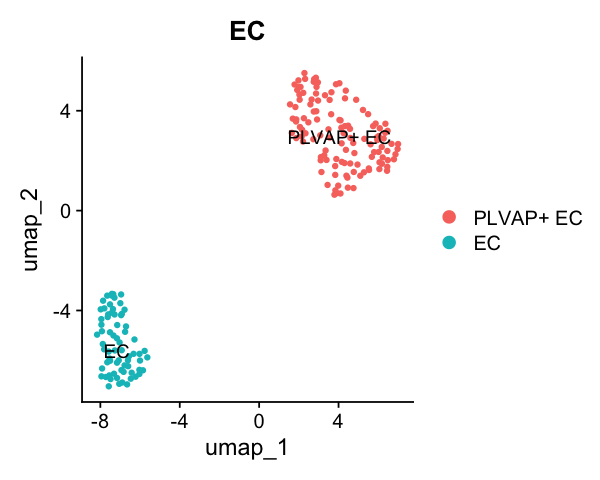

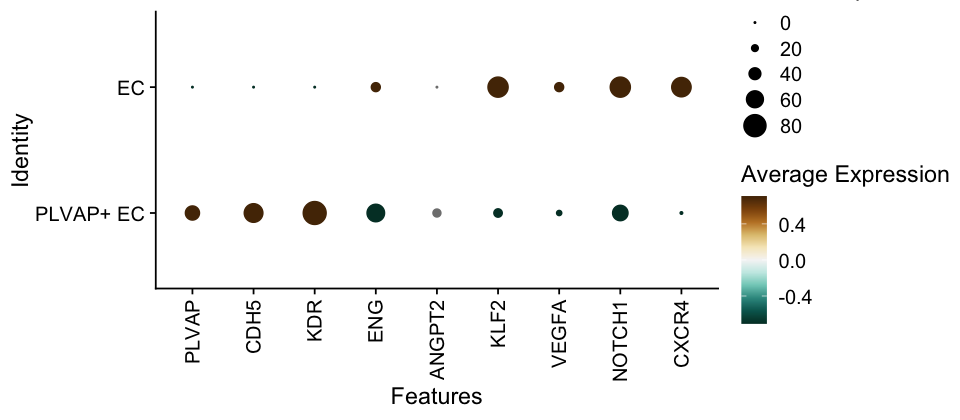

In [25]:
options(repr.plot.width = 5, repr.plot.height = 4)

DimPlot(
  EC,
  reduction = "umap",
  group.by = "celltype",
  label = TRUE
) +
  ggtitle("EC")

options(repr.plot.width = 8, repr.plot.height = 3.5)

DotPlot(
  EC,
  features = c(
    "PLVAP", "CDH5", "KDR", "ERNB2", 'ENG',
    "ANGPT2", 'KLF2', "VEGFA", "NOTCH1", "CXCR4"
  ),
  group.by = "celltype"
) +
  scale_colour_gradientn(
    colours = rev(RColorBrewer::brewer.pal(n = 11, name = "BrBG"))
  ) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
